# 4. Кластеризацiя k-Means

**k-Means** -- один з найпопулярнiших алгоритмiв кластеризацiї, який розбиває данi на *k* кластерiв,
мiнiмiзуючи суму квадратiв вiдстаней вiд кожної точки до центроїда її кластера (iнерцiя / SSE).

**Етапи роботи:**
1. Iнiцiалiзацiя *k* центроїдiв (k-means++).
2. Призначення кожної точки найближчому центроїду.
3. Перерахунок центроїдiв як середнього по кластеру.
4. Повторення крокiв 2-3 до збiжностi.

Кластеризацiя виконується на **парах атрибутiв** з найвищим lift (визначених Apriori/FP-Growth).

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.data_loader import create_scaled, subsample
from src.visualization import plot_cluster_scatter_2d, plot_silhouette_curve, plot_elbow
from src.evaluation import compute_metrics, find_best_k, build_results_row, save_results
from src.clustering import run_kmeans, get_cluster_profiles

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv(PROCESSED_PATH)
with open(TOP_PAIRS_PATH) as f:
    pairs = json.load(f)

n_sample = SAMPLE_SIZES['kmeans']
df_sub = subsample(df, n_sample)
print(f"Повний датасет: {len(df)}, підвибірка для кластеризації: {len(df_sub)}")
print(f"Пари для кластеризації: {pairs}")

Повний датасет: 89741, підвибірка для кластеризації: 20000
Пари для кластеризації: [['loudness', 'speechiness'], ['loudness', 'valence'], ['speechiness', 'valence'], ['energy', 'loudness']]


## 4.1 Пiдбiр оптимального k для кожної пари

Для кожної пари ознак будуємо:
- **Метод лiктя (Elbow)** -- графiк iнерцiї (SSE) вiд кiлькостi кластерiв.
- **Silhouette Score** -- мiра якостi кластеризацiї (чим ближче до 1, тим краще).

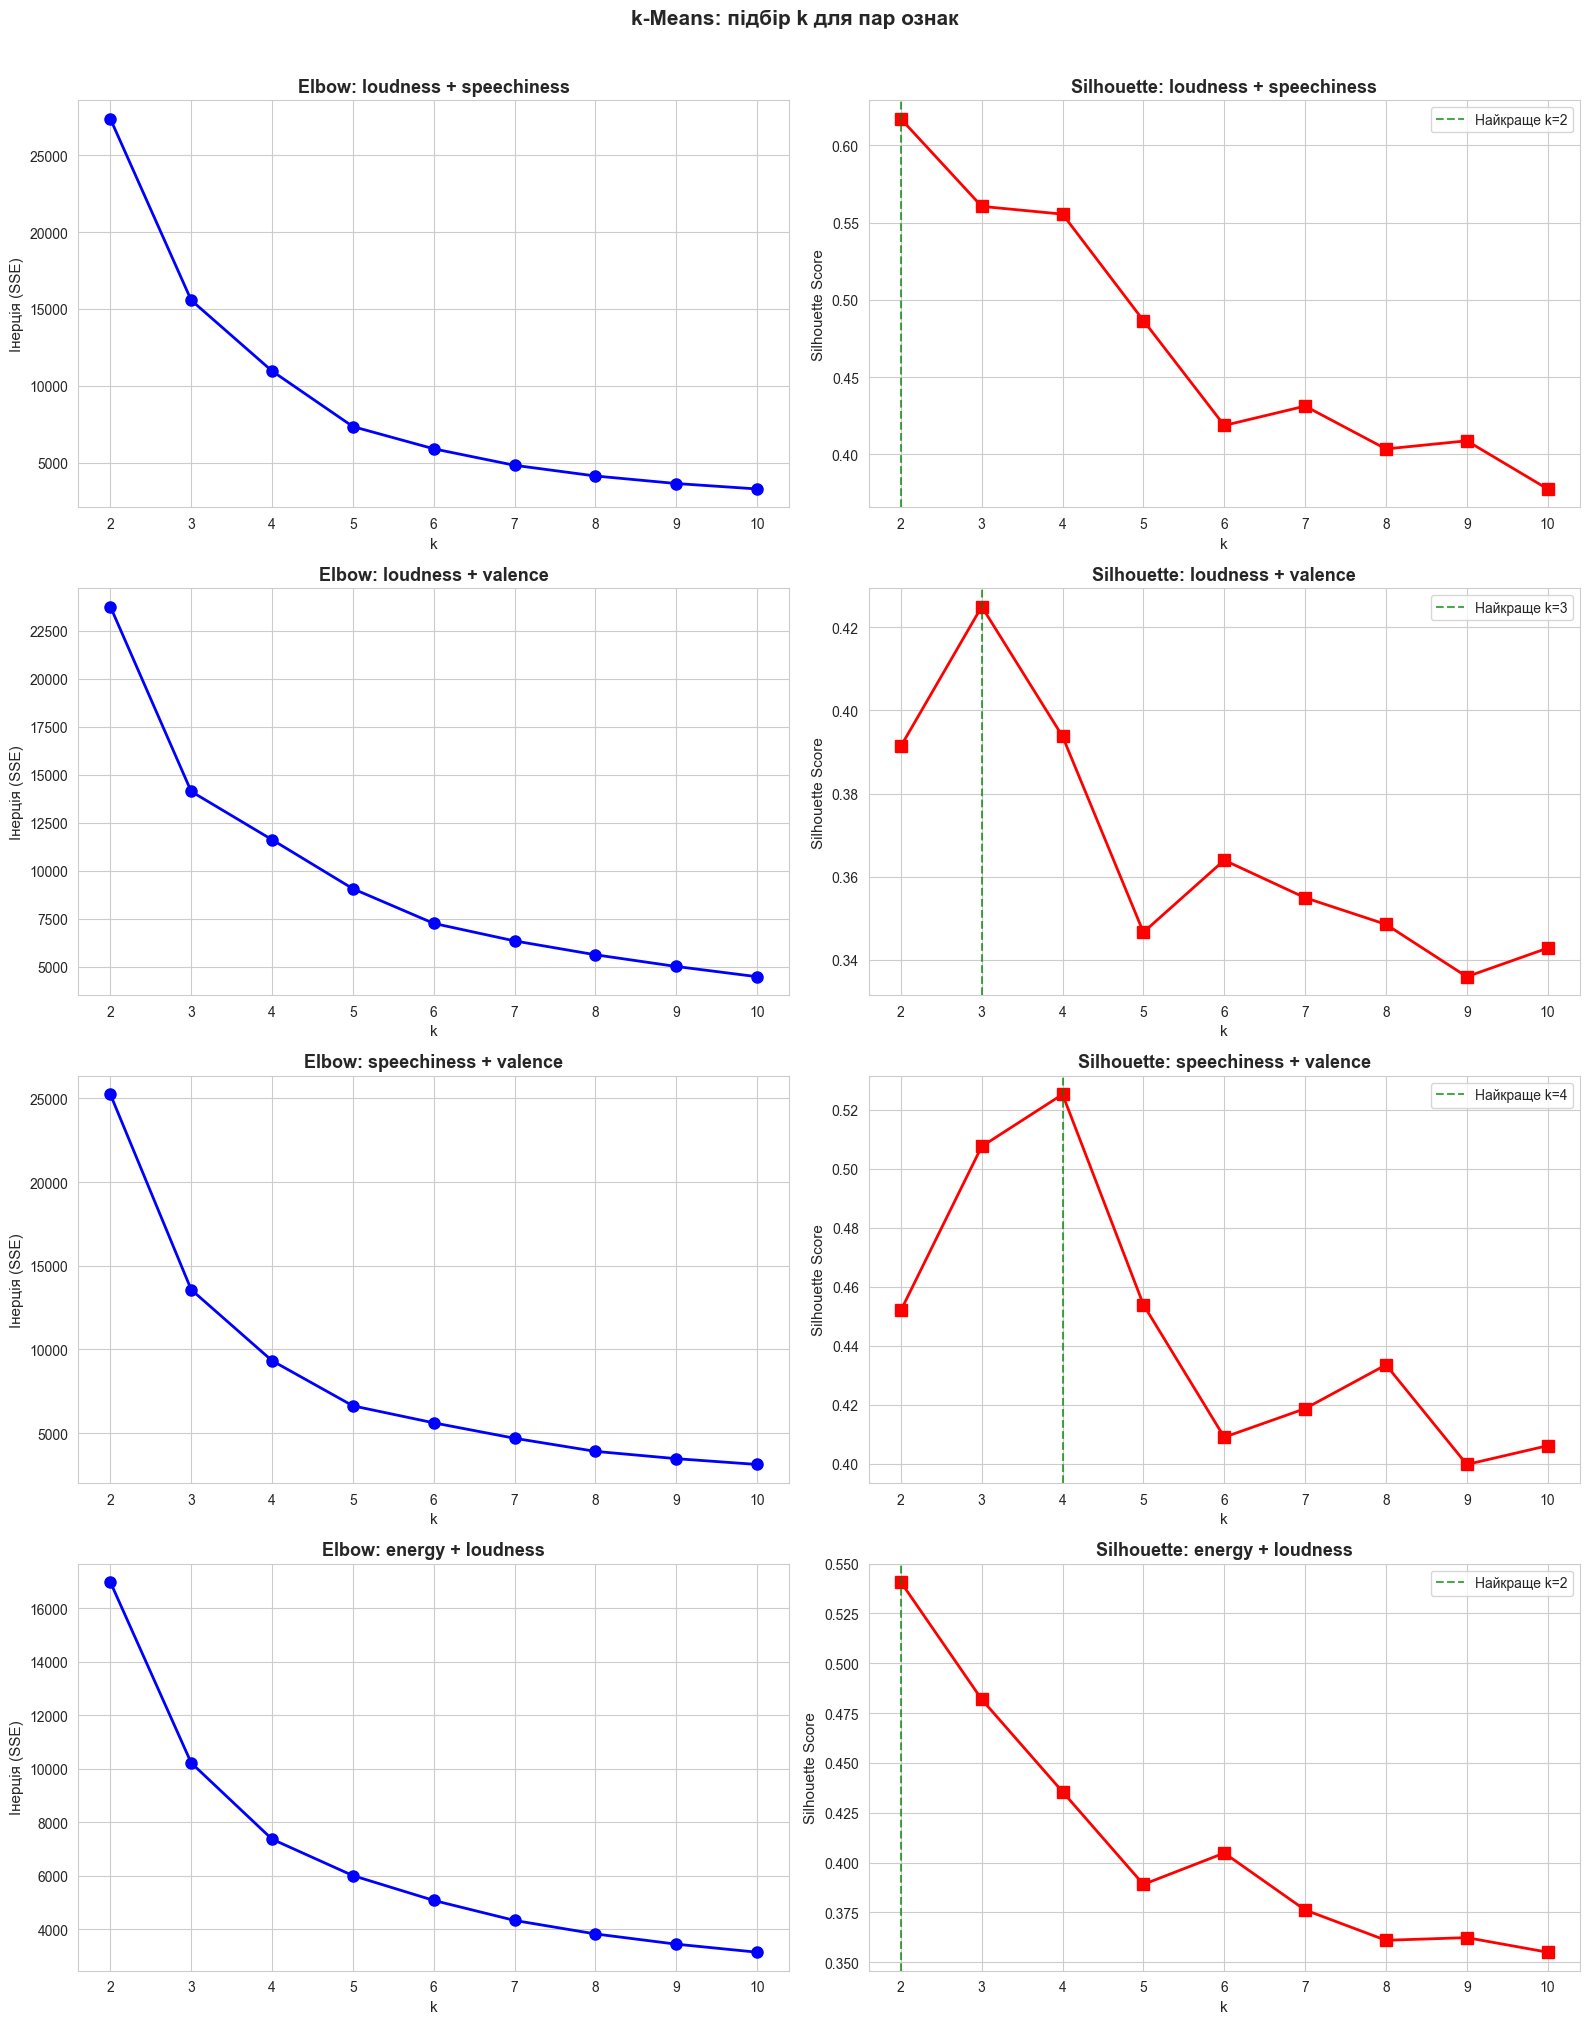

loudness + speechiness: найкращий k = 2
loudness + valence: найкращий k = 3
speechiness + valence: найкращий k = 4
energy + loudness: найкращий k = 2


In [3]:
best_k_pairs = {}
n_pairs = len(pairs)

fig, axes = plt.subplots(n_pairs, 2, figsize=(16, 5 * n_pairs))
if n_pairs == 1:
    axes = axes.reshape(1, -1)

for i, pair in enumerate(pairs):
    X_pair, _ = create_scaled(df_sub, pair)
    X_arr = X_pair.values

    best_k, sil_scores = find_best_k(
        X_arr, K_RANGE, lambda X, k: run_kmeans(X, k)[0]
    )
    best_k_pairs[i] = best_k

    inertias = []
    for k in K_RANGE:
        _, model = run_kmeans(X_arr, k)
        inertias.append(model.inertia_)

    plot_elbow(K_RANGE, inertias,
              f'Elbow: {pair[0]} + {pair[1]}', ax=axes[i, 0])
    plot_silhouette_curve(K_RANGE, sil_scores,
                         f'Silhouette: {pair[0]} + {pair[1]}', ax=axes[i, 1])

plt.suptitle('k-Means: підбір k для пар ознак', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

for i, pair in enumerate(pairs):
    print(f"{pair[0]} + {pair[1]}: найкращий k = {best_k_pairs[i]}")

## 4.2 Кластеризацiя пар та 2D-вiзуалiзацiя

Запуск k-Means з оптимальним k для кожної пари. Вiзуалiзацiя кластерiв у 2D з позначенням центроїдiв.

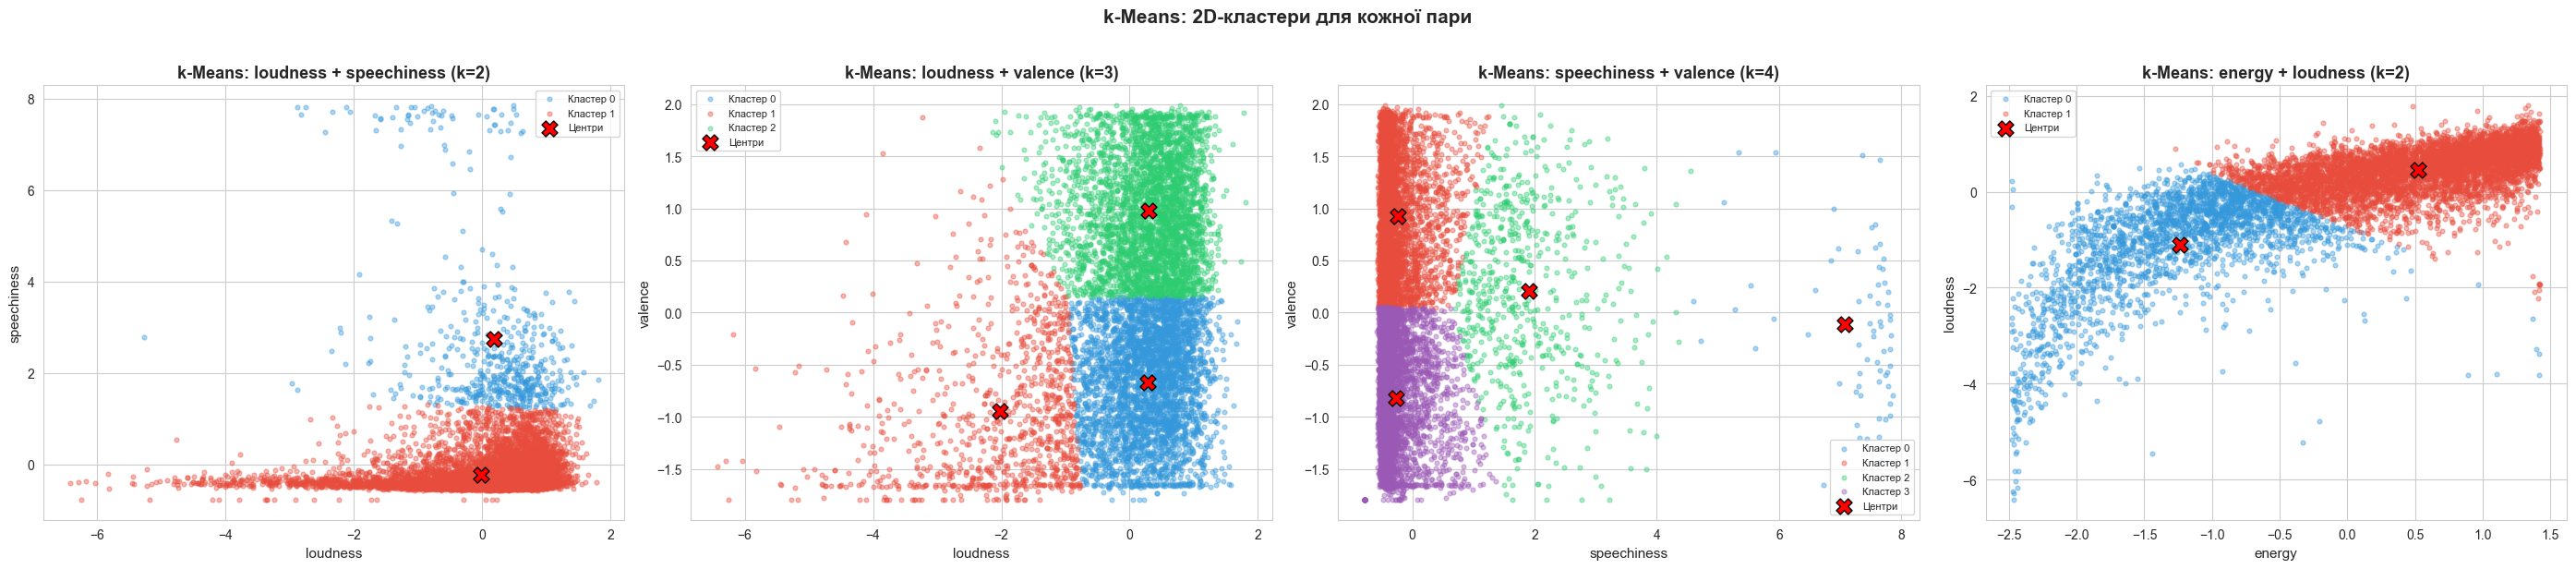


Метрики по парах:
  loudness + speechiness: k=2, Sil=0.6172, DB=0.7876, Час=0.0412с
  loudness + valence: k=3, Sil=0.4250, DB=0.8159, Час=0.0654с
  speechiness + valence: k=4, Sil=0.5252, DB=0.6187, Час=0.0567с
  energy + loudness: k=2, Sil=0.5408, DB=0.7170, Час=0.0387с


In [4]:
results = []
pair_labels = {}
fig, axes = plt.subplots(1, len(pairs), figsize=(7 * len(pairs), 6))
if len(pairs) == 1:
    axes = [axes]

for i, pair in enumerate(pairs):
    X_pair, _ = create_scaled(df_sub, pair)
    X_arr = X_pair.values
    best_k = best_k_pairs[i]

    start = time.time()
    labels, model = run_kmeans(X_arr, best_k)
    pair_labels[i] = labels
    elapsed = time.time() - start

    metrics = compute_metrics(X_arr, labels)
    results.append(
        build_results_row('k-Means', f'{pair[0]} + {pair[1]}',
                          best_k, metrics, elapsed)
    )

    plot_cluster_scatter_2d(
        X_arr, labels, pair,
        f'k-Means: {pair[0]} + {pair[1]} (k={best_k})',
        centers=model.cluster_centers_, ax=axes[i]
    )

plt.suptitle('k-Means: 2D-кластери для кожної пари', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nМетрики по парах:")
for r in results:
    print(f"  {r['pair']}: k={r['k']}, Sil={r['silhouette']:.4f}, "
          f"DB={r['davies_bouldin']:.4f}, Час={r['time_sec']:.4f}с")

## 4.3 Жанровий склад кластерiв

Аналiз розподiлу музичних жанрiв мiж кластерами для кожної пари ознак.

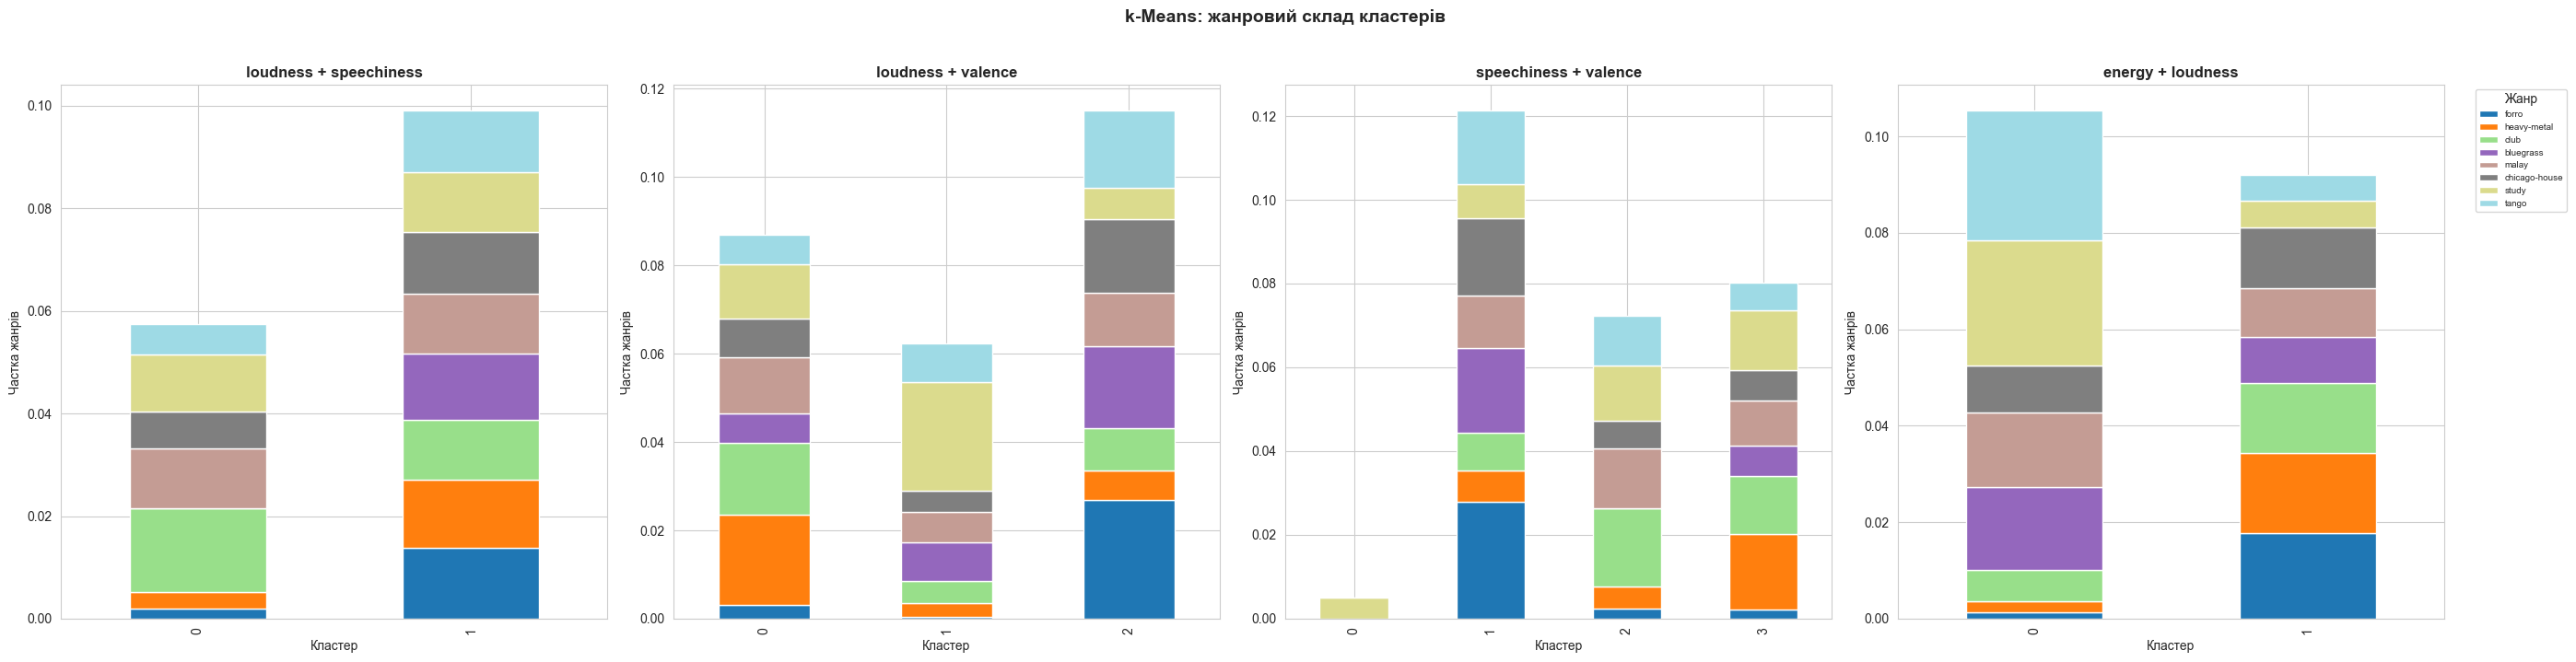

In [5]:
fig, axes = plt.subplots(1, len(pairs), figsize=(7 * len(pairs), 7))
if len(pairs) == 1:
    axes = [axes]

for i, pair in enumerate(pairs):
    df_temp = df_sub.copy()
    df_temp['cluster'] = pair_labels[i]
    top_genres = df_sub[GENRE_COL].value_counts().head(8).index
    genre_ct = pd.crosstab(df_temp['cluster'], df_temp[GENRE_COL], normalize='index')
    cols = [c for c in top_genres if c in genre_ct.columns]
    genre_ct[cols].plot(kind='bar', stacked=True, ax=axes[i], colormap='tab20', legend=False)
    axes[i].set_title(f'{pair[0]} + {pair[1]}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Кластер')
    axes[i].set_ylabel('Частка жанрiв')

axes[-1].legend(title='Жанр', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.suptitle('k-Means: жанровий склад кластерiв', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
save_results(results, 'results_kmeans.csv')

print("\nПiдсумкова таблиця результатiв k-Means:")
print(pd.DataFrame(results).to_string(index=False))

Результати збережено: F:\University\Магістр\Data Mining\Lab2-Data-Mining-2026\results\results_kmeans.csv

Пiдсумкова таблиця результатiв k-Means:
algorithm                   pair  k  silhouette  davies_bouldin  time_sec
  k-Means loudness + speechiness  2    0.617192        0.787584    0.0412
  k-Means     loudness + valence  3    0.425006        0.815895    0.0654
  k-Means  speechiness + valence  4    0.525207        0.618704    0.0567
  k-Means      energy + loudness  2    0.540759        0.716952    0.0387


## Пiдсумок

**Основнi результати кластеризацiї k-Means:**

1. **Пiдбiр k**: для кожної пари ознак визначено оптимальне k за Silhouette Score та методом лiктя.
2. **Пари ознак**: 2D-кластеризацiя дозволяє наочно побачити структуру даних; якiсть залежить вiд обраної пари.
3. **Жанровий аналiз**: кластери не повнiстю збiгаються з жанрами, що свiдчить про перетин аудiо-характеристик мiж жанрами.

Результати збережено у `results/results_kmeans.csv` для подальшого порiвняння з iншими алгоритмами.